<a href="https://colab.research.google.com/github/mkg6573/dominant-color-detector/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib
import matplotlib.pyplot as plt

In [3]:
image = matplotlib.image.imread('/content/file_00000000a28461f7a8ce5780aa3cdf30_conversation_id=680080f4-0404-8009-b3ec-cff9c0efd07e&message_id=77fb83b5-3e2f-4e60-88aa-21ca249c96b0.PNG')

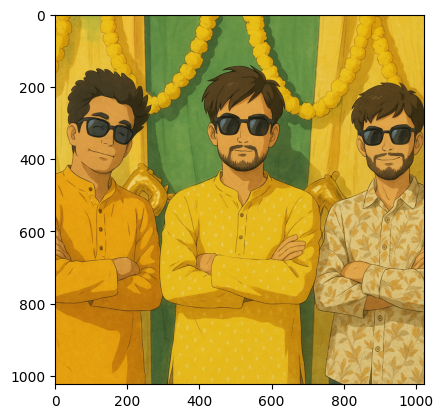

In [4]:
plt.imshow(image)

In [30]:
np.array(image)

array([[[0.91764706, 0.74509805, 0.18431373],
        [0.9254902 , 0.7490196 , 0.18431373],
        [0.92941177, 0.7490196 , 0.1764706 ],
        ...,
        [0.88235295, 0.7529412 , 0.2       ],
        [0.8862745 , 0.7529412 , 0.20392157],
        [0.9098039 , 0.75686276, 0.23529412]],

       [[0.9254902 , 0.74509805, 0.18431373],
        [0.9137255 , 0.7529412 , 0.17254902],
        [0.91764706, 0.75686276, 0.18431373],
        ...,
        [0.88235295, 0.7411765 , 0.21568628],
        [0.9019608 , 0.75686276, 0.22745098],
        [0.89411765, 0.7647059 , 0.23529412]],

       [[0.9254902 , 0.7529412 , 0.19215687],
        [0.9137255 , 0.75686276, 0.19215687],
        [0.92941177, 0.76862746, 0.20392157],
        ...,
        [0.8862745 , 0.7411765 , 0.21176471],
        [0.8980392 , 0.75686276, 0.23529412],
        [0.8901961 , 0.74509805, 0.21960784]],

       ...,

       [[0.8901961 , 0.6117647 , 0.0627451 ],
        [0.8862745 , 0.627451  , 0.05882353],
        [0.89411765, 0

In [5]:
image.shape

(1024, 1024, 3)

In [7]:
X = image.reshape(-1,3)
X

array([[0.91764706, 0.74509805, 0.18431373],
       [0.9254902 , 0.7490196 , 0.18431373],
       [0.92941177, 0.7490196 , 0.1764706 ],
       ...,
       [0.8117647 , 0.654902  , 0.32941177],
       [0.80784315, 0.6509804 , 0.33333334],
       [0.7921569 , 0.65882355, 0.3372549 ]], dtype=float32)

In [8]:
X.shape

(1048576, 3)

In [9]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

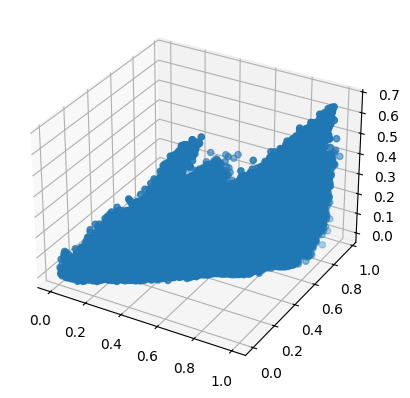

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,0], X[:,1], X[:,2])

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

KMeans(n_clusters=3)

In [18]:
kmeans.cluster_centers_

array([[0.34645265, 0.39245293, 0.18190731],
       [0.8511564 , 0.69524014, 0.3182345 ],
       [0.8346933 , 0.6241571 , 0.09961966]], dtype=float32)

In [19]:
from PIL import Image, ImageDraw
import numpy as np

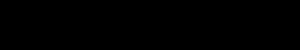

In [13]:
Image.new("RGB",(300, 50))

In [24]:
def create_color_palette(dominant_colors, palette_size=(300, 50)):
    # Create an image to display the colors
    palette = Image.new("RGB", palette_size)
    draw = ImageDraw.Draw(palette)

    # Calculate the width of each color swatch
    swatch_width = palette_size[0] // len(dominant_colors)

    # Draw each color as a rectangle on the palette
    for i, color in enumerate(dominant_colors):
        draw.rectangle([i * swatch_width, 0, (i + 1) * swatch_width, palette_size[1]], fill=tuple(color))

    return palette

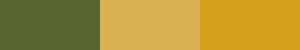

In [29]:
create_color_palette((kmeans.cluster_centers_*255).astype(int))

In [27]:
kmeans.cluster_centers_*255

array([[ 88.34543 , 100.07549 ,  46.386364],
       [217.04489 , 177.28624 ,  81.149796],
       [212.8468  , 159.16005 ,  25.403013]], dtype=float32)